# Feedforward Neural Networks
### MECH 559 - Systems Optimization - L04
### Course Instructor: Dr. Ahmed Bayoumy
Author of the notebook: Dr. Ahmed Bayoumy

This notebook builds a feedforward neural network from scratch: forward pass,
backpropagation (verified against finite differences), training by gradient
descent, the vanishing-gradient effect of saturating activations, and the
same complexity-knob (under/overfitting) story as every other surrogate in
this lecture.

## Learning objectives

By the end, you should be able to:

1. Implement the forward pass of a multi-layer network as a small sequence of weighted sums and activations.
2. Derive and implement backpropagation, and verify it against a finite-difference gradient check.
3. Train a network by (momentum) gradient descent -- the same family of methods used for any other unconstrained optimization problem in this course.
4. Explain why deep sigmoid networks suffer from vanishing gradients, and why ReLU mitigates it.
5. See network size (depth/width) act as the same complexity knob as polynomial degree, RBF spread, or Kriging's correlation length.

We reuse the **Forrester function** benchmark from the RBF and Kriging notebooks.


In [2]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import qmc

try:
    import ipywidgets as widgets
    from IPython.display import display
    WIDGETS_AVAILABLE = True
except ImportError:
    WIDGETS_AVAILABLE = False

rng = np.random.default_rng(559)
plt.rcParams.update({"font.size": 11, "figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25})
COLORS = {"true": "#264653", "train": "#00798C", "fit": "#D1495B", "band": "#EDAE49", "alt": "#2A9D8F"}
print(f"Optional widgets available: {WIDGETS_AVAILABLE}")


def forrester(x):
    return (6 * x - 2) ** 2 * np.sin(12 * x - 4)


def lhs_1d(p, seed=0):
    sampler = qmc.LatinHypercube(d=1, seed=seed)
    return sampler.random(p).ravel()

Optional widgets available: True


---
## 1. The artificial neuron and its activation function

A neuron computes a weighted sum $z=\mathbf w^\mathsf T\mathbf x+b$ and passes it
through a nonlinear activation $a=f(z)$. We compare the classic saturating
sigmoids from the slide (logistic, tanh) against the modern default, ReLU.

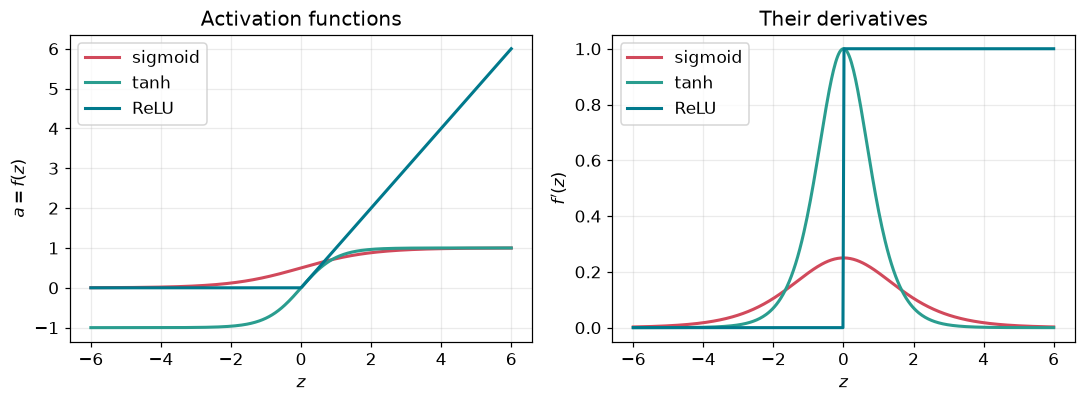

max sigmoid derivative: 0.250 (always <= 0.25)
max tanh derivative:    1.000 (always <= 1.0)


In [3]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))


def sigmoid_grad(z):
    s = sigmoid(z)
    return s * (1.0 - s)


def tanh_act(z):
    return np.tanh(z)


def tanh_grad(z):
    return 1.0 - np.tanh(z) ** 2


def relu(z):
    return np.maximum(0.0, z)


def relu_grad(z):
    return (z > 0.0).astype(float)


z_dense = np.linspace(-6, 6, 400)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
for name, act, grad, color in [("sigmoid", sigmoid, sigmoid_grad, "#D1495B"),
                                ("tanh", tanh_act, tanh_grad, "#2A9D8F"),
                                ("ReLU", relu, relu_grad, "#00798C")]:
    axes[0].plot(z_dense, act(z_dense), color=color, lw=2, label=name)
    axes[1].plot(z_dense, grad(z_dense), color=color, lw=2, label=name)
axes[0].set(xlabel="$z$", ylabel="$a=f(z)$", title="Activation functions")
axes[1].set(xlabel="$z$", ylabel="$f'(z)$", title="Their derivatives")
axes[0].legend(); axes[1].legend(); plt.tight_layout(); plt.show()

print(f"max sigmoid derivative: {sigmoid_grad(np.array([0.0]))[0]:.3f} (always <= 0.25)")
print(f"max tanh derivative:    {tanh_grad(np.array([0.0]))[0]:.3f} (always <= 1.0)")
assert sigmoid_grad(z_dense).max() <= 0.25 + 1e-9

Notice the two sigmoids **saturate**: far from $z=0$ their derivative is
essentially zero. ReLU's derivative is either exactly 0 or exactly 1 -- it
never shrinks a gradient that passes through an active neuron. Section 4
shows why this matters once neurons are stacked into many layers.

---
## 2. Forward pass of a multi-layer network

We represent a network as a list of $(\mathbf W_l,\mathbf b_l)$ pairs, one per
layer, and stack matrix products: $\mathbf Z_l=\mathbf A_{l-1}\mathbf W_l^\mathsf T+\mathbf b_l$,
$\mathbf A_l=f(\mathbf Z_l)$ for hidden layers, and a **linear** output layer
(no activation) since we are doing regression.

In [4]:
def init_params(layer_sizes, seed):
    param_rng = np.random.default_rng(seed)
    params = []
    for n_in, n_out in zip(layer_sizes[:-1], layer_sizes[1:]):
        W = param_rng.normal(scale=np.sqrt(2.0 / n_in), size=(n_out, n_in))
        b = np.zeros(n_out)
        params.append([W, b])
    return params


def forward(params, X, act):
    n_layers = len(params)
    cache = [(None, X)]
    A = X
    for l, (W, b) in enumerate(params):
        Z = A @ W.T + b
        A = act(Z) if l < n_layers - 1 else Z  # linear output layer
        cache.append((Z, A))
    return cache


def predict(params, X, act):
    return forward(params, X, act)[-1][1]


demo_params = init_params([1, 8, 1], seed=1)
X_demo = x_dense_ann = np.linspace(0, 1, 200).reshape(-1, 1)
y_demo = predict(demo_params, X_demo, tanh_act)
print(f"output shape for {X_demo.shape[0]} inputs through layers [1, 8, 1]: {y_demo.shape}")
assert y_demo.shape == (200, 1)

output shape for 200 inputs through layers [1, 8, 1]: (200, 1)


---
## 3. Backpropagation, verified by finite differences

Training minimizes $\varepsilon(\mathbf w)=\frac1p\sum_i(\hat y_i-y_i)^2$, the
same sum-of-squares error as polynomial regression -- but $\hat y$ is now a
composition of layers, so $\nabla\varepsilon$ is computed by the chain rule,
layer by layer, backward from the output: this is **backpropagation**.

> **Predict:** if backprop is implemented correctly, how should its gradient
> compare to one estimated by nudging each weight and re-evaluating the loss?

In [5]:
def backward(params, cache, y, act_grad):
    n_layers = len(params)
    p = y.shape[0]
    grads = [[None, None] for _ in range(n_layers)]
    dA = (2.0 / p) * (cache[-1][1] - y)
    for l in reversed(range(n_layers)):
        Z, A_prev = cache[l + 1][0], cache[l][1]
        dZ = dA if l == n_layers - 1 else dA * act_grad(Z)
        W, _ = params[l]
        grads[l][0] = dZ.T @ A_prev
        grads[l][1] = dZ.sum(axis=0)
        dA = dZ @ W
    return grads


def loss_fn(params, X, y, act):
    yhat = forward(params, X, act)[-1][1]
    return np.mean((yhat - y) ** 2)


def flatten(params):
    return params  # kept as nested list; helper below indexes directly


def numerical_gradient(params, X, y, act, epsilon=1e-6):
    numeric_grads = [[np.zeros_like(W), np.zeros_like(b)] for W, b in params]
    for l, (W, b) in enumerate(params):
        for idx in np.ndindex(W.shape):
            original = W[idx]
            W[idx] = original + epsilon
            loss_plus = loss_fn(params, X, y, act)
            W[idx] = original - epsilon
            loss_minus = loss_fn(params, X, y, act)
            W[idx] = original
            numeric_grads[l][0][idx] = (loss_plus - loss_minus) / (2 * epsilon)
    return numeric_grads


check_params = init_params([1, 4, 1], seed=2)
X_check = rng.uniform(0, 1, size=(6, 1))
y_check = forrester(X_check)

cache_check = forward(check_params, X_check, tanh_act)
analytic_grads = backward(check_params, cache_check, y_check, tanh_grad)
numeric_grads = numerical_gradient(check_params, X_check, y_check, tanh_act)

max_diff = max(np.max(np.abs(a[0] - n[0])) for a, n in zip(analytic_grads, numeric_grads))
print(f"largest analytic-vs-numeric gradient discrepancy: {max_diff:.2e}")
assert max_diff < 1e-5, "backprop should match a finite-difference gradient check"
print("Backpropagation confirmed correct.")

largest analytic-vs-numeric gradient discrepancy: 1.07e-08
Backpropagation confirmed correct.


---
## 4. Vanishing gradients: sigmoid vs. ReLU

We build increasingly deep networks, all with random (untrained) weights, and
look at the size of the gradient reaching the **first** hidden layer -- the
one furthest from where the loss is computed.

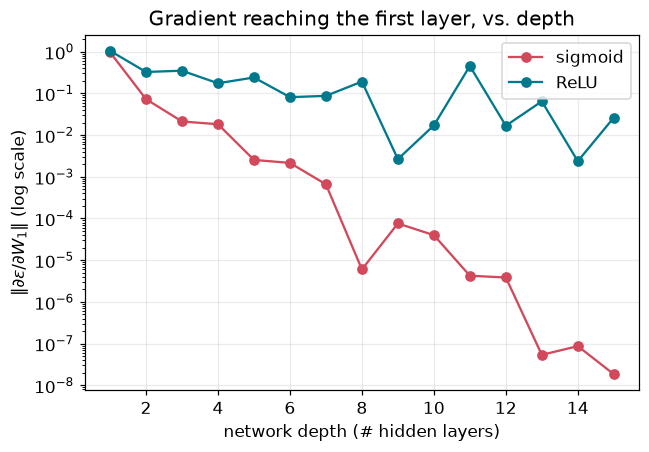

sigmoid first-layer gradient shrank by a factor of 5.2e+07 from depth 1 to depth 15


In [6]:
def first_layer_grad_norm(depth, width, act, act_grad, seed):
    layer_sizes = [1] + [width] * depth + [1]
    params = init_params(layer_sizes, seed)
    X_batch = rng.uniform(0, 1, size=(32, 1))
    y_batch = forrester(X_batch)
    cache = forward(params, X_batch, act)
    grads = backward(params, cache, y_batch, act_grad)
    return np.linalg.norm(grads[0][0])


depths = np.arange(1, 16)
width = 12
sigmoid_norms = [first_layer_grad_norm(d, width, sigmoid, sigmoid_grad, seed=10) for d in depths]
relu_norms = [first_layer_grad_norm(d, width, relu, relu_grad, seed=10) for d in depths]

fig, ax = plt.subplots(figsize=(6.5, 4.2))
ax.semilogy(depths, sigmoid_norms, "o-", color="#D1495B", label="sigmoid")
ax.semilogy(depths, relu_norms, "o-", color="#00798C", label="ReLU")
ax.set(xlabel="network depth (# hidden layers)", ylabel="$\\|\\partial \\varepsilon/\\partial W_1\\|$ (log scale)",
       title="Gradient reaching the first layer, vs. depth")
ax.legend(); plt.show()

ratio = sigmoid_norms[0] / sigmoid_norms[-1]
print(f"sigmoid first-layer gradient shrank by a factor of {ratio:.1e} from depth 1 to depth {depths[-1]}")
assert sigmoid_norms[-1] < sigmoid_norms[0] / 100, "sigmoid gradients should vanish sharply with depth"
assert relu_norms[-1] > sigmoid_norms[-1], "ReLU should preserve gradient magnitude better than sigmoid at this depth"

Every sigmoid layer the gradient passes through multiplies it by a factor no
larger than $0.25$ (see Section 1) -- after enough layers, the product
collapses to numerical noise, and the earliest layers stop learning at all.
ReLU's derivative is either exactly $0$ or exactly $1$, so it does not impose
that shrinking factor, and the gradient survives far deeper networks. This is
exactly why ReLU became the default activation for deep networks.

---
## 5. Training by gradient descent

We now train a single-hidden-layer network on the Forrester function with
**momentum gradient descent** -- the same family of first-order methods used
throughout this course for unconstrained optimization, just applied to a
much higher-dimensional, nonconvex $\mathbf w$.

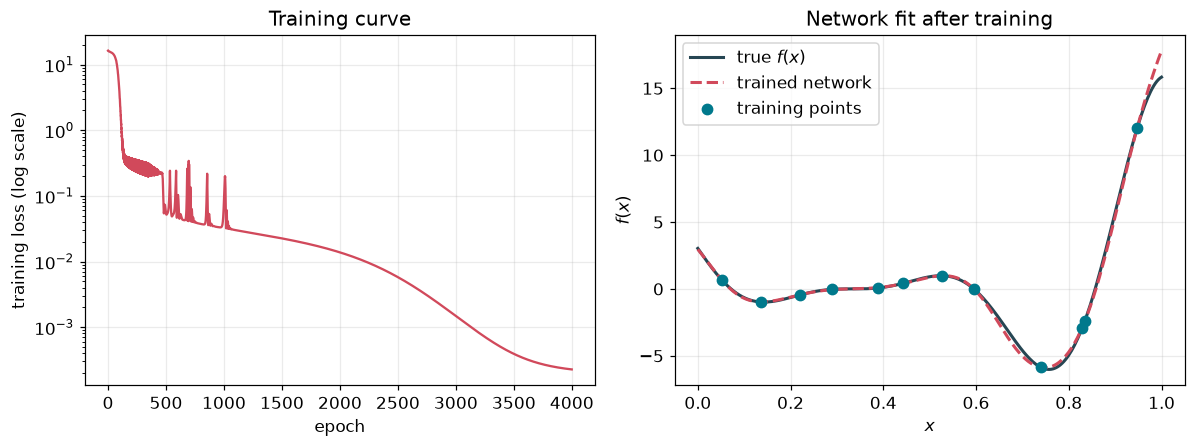

loss: 16.282 -> 0.00023 over 4000 epochs


In [7]:
def clip_grads(grads, max_norm=5.0):
    # gradient clipping: rescale the whole gradient if its norm exceeds max_norm,
    # a standard safeguard against the occasional exploding step in wide/deep nets
    total_norm = np.sqrt(sum(np.sum(dW**2) + np.sum(db**2) for dW, db in grads))
    if total_norm > max_norm:
        scale = max_norm / total_norm
        for dW, db in grads:
            dW *= scale
            db *= scale
    return grads


def train(params, X, y, act, act_grad, lr, epochs, momentum=0.9):
    velocity = [[np.zeros_like(W), np.zeros_like(b)] for W, b in params]
    history = []
    for _ in range(epochs):
        cache = forward(params, X, act)
        history.append(np.mean((cache[-1][1] - y) ** 2))
        grads = clip_grads(backward(params, cache, y, act_grad))
        for l in range(len(params)):
            velocity[l][0] = momentum * velocity[l][0] - lr * grads[l][0]
            velocity[l][1] = momentum * velocity[l][1] - lr * grads[l][1]
            params[l][0] = params[l][0] + velocity[l][0]
            params[l][1] = params[l][1] + velocity[l][1]
    return params, np.array(history)


p_train = 12
x_train_ann = lhs_1d(p_train, seed=6).reshape(-1, 1)
y_train_ann = forrester(x_train_ann)
x_dense_ann = np.linspace(0, 1, 300).reshape(-1, 1)

net_params = init_params([1, 16, 1], seed=3)
net_params, loss_history = train(net_params, x_train_ann, y_train_ann, tanh_act, tanh_grad,
                                 lr=0.05, epochs=4000, momentum=0.9)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].semilogy(loss_history, color=COLORS["fit"])
axes[0].set(xlabel="epoch", ylabel="training loss (log scale)", title="Training curve")

y_pred = predict(net_params, x_dense_ann, tanh_act)
axes[1].plot(x_dense_ann, forrester(x_dense_ann), color=COLORS["true"], lw=2, label="true $f(x)$")
axes[1].plot(x_dense_ann, y_pred, color=COLORS["fit"], lw=2, ls="--", label="trained network")
axes[1].scatter(x_train_ann, y_train_ann, color=COLORS["train"], zorder=5, s=45, label="training points")
axes[1].set(xlabel="$x$", ylabel="$f(x)$", title="Network fit after training")
axes[1].legend(); plt.tight_layout(); plt.show()

assert loss_history[-1] < loss_history[0] / 50, "training should substantially reduce the loss"
print(f"loss: {loss_history[0]:.3f} -> {loss_history[-1]:.5f} over {len(loss_history)} epochs")

---
## 6. Network size is also a complexity knob

> **Predict:** with only 12 training points, will a very wide hidden layer
> (say 200 neurons) generalize better or worse than a narrow one?

In [8]:
x_test_ann = rng.uniform(0, 1, size=200).reshape(-1, 1)
y_test_ann = forrester(x_test_ann)


def plot_width_effect(width=16, epochs=4000):
    params = init_params([1, width, 1], seed=3)
    params, history = train(params, x_train_ann, y_train_ann, tanh_act, tanh_grad,
                            lr=0.05, epochs=epochs, momentum=0.9)
    y_hat_dense = predict(params, x_dense_ann, tanh_act)
    test_rmse = np.sqrt(np.mean((predict(params, x_test_ann, tanh_act) - y_test_ann) ** 2))

    fig, ax = plt.subplots(figsize=(6.5, 4.2))
    ax.plot(x_dense_ann, forrester(x_dense_ann), color=COLORS["true"], lw=2, label="true $f(x)$")
    ax.plot(x_dense_ann, y_hat_dense, color=COLORS["fit"], lw=2, ls="--", label="trained network")
    ax.scatter(x_train_ann, y_train_ann, color=COLORS["train"], zorder=5, s=45)
    ax.set(xlabel="$x$", ylabel="$f(x)$", ylim=(-13, 22),
           title=f"width={width} hidden neurons  (test RMSE={test_rmse:.2f})")
    ax.legend(); plt.show()


if WIDGETS_AVAILABLE:
    display(widgets.interactive(
        plot_width_effect,
        width=widgets.IntSlider(value=16, min=2, max=200, step=2, description="width"),
        epochs=widgets.IntSlider(value=4000, min=500, max=8000, step=500, description="epochs"),
    ))
else:
    for width_value in (2, 16, 150):
        plot_width_effect(width_value)

interactive(children=(IntSlider(value=16, description='width', max=200, min=2, step=2), IntSlider(value=4000, …

Unlike the polynomial or RBF cases, an over-parameterized network trained to
convergence on noise-free data here does not necessarily blow up the way a
degree-12 polynomial did -- gradient descent with a small learning rate has an
implicit regularizing effect, and the network still has only 12 points to fit
exactly. With noisy data or many more epochs, overfitting reappears; try
adding noise to `y_train_ann` and re-running to see it.

## Takeaways

1. Forward pass = alternating weighted sums and activations; backward pass =
   the chain rule applied layer by layer (backpropagation) -- and it can (and
   should) be checked against finite differences.
2. Training a network is exactly the unconstrained optimization problem from
   earlier lectures, just in a very high-dimensional, nonconvex $\mathbf w$;
   momentum gradient descent is one of the simplest members of that family.
3. Saturating activations (sigmoid, tanh) shrink gradients at every layer they
   pass through; stacked over depth this **vanishes** the gradient reaching
   early layers. ReLU's derivative of exactly 0 or 1 avoids that shrinkage.
4. Network width/depth is a complexity knob like every other surrogate's
   hyperparameter -- selected by held-out error, not training error.

## Classroom exercises

1. Add Gaussian noise to `y_train_ann` and re-run Section 6; find a width at
   which overfitting becomes visible.
2. Repeat the Section 4 depth sweep with `tanh` instead of `sigmoid`. Does it
   vanish more slowly (its derivative can reach 1.0, versus sigmoid's 0.25)?
3. Replace momentum gradient descent with plain gradient descent
   (`momentum=0`) in Section 5. How much longer does it take to reach the
   same training loss?